In [ ]:
from os import walk, path, name as osname
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
RAW_DATA = './data/raw'
TRAIN_DATA = './data/train'
TEST_DATA = './data/test'
TEST_SIZE = 0.3

In [3]:
from subprocess import Popen, PIPE, STDOUT
from IPython.core.magic import register_line_magic

@register_line_magic
def runshell(command):
    with Popen(
        command, stdout=PIPE, shell=True, stderr=STDOUT, bufsize=1, close_fds=True
    ) as process:
        for line in iter(process.stdout.readline, b""):
            print(line.decode("utf-8"), end='')

In [ ]:
# Convert this cell to 'Code' to build mltextclassifier.exe
if osname == 'nt':
    %runshell cd ..\.. && mkdir build && cd build && cmake .. >> buildlog.txt 2>&1
    %runshell cd ..\..\build && cmake --build . --config Release >> buildlog.txt 2>&1
    %runshell copy ..\..\build\Release\mltextclassifier.exe .

    MLTEXTCLASSIFIER = "mltextclassifier.exe"
else:
    %runshell cd ../.. && mkdir build && cd build && cmake .. >> buildlog.txt 2>&1
    %runshell cd ../../build && cmake --build . --config Release >> buildlog.txt 2>&1
    %runshell cp ../../build/mltextclassifier .

    MLTEXTCLASSIFIER = "./mltextclassifier"

c:\users\rajas\appdata\local\programs\python\python39\lib\subprocess.py:937: RuntimeWarning: line buffering (buffering=1) isn't supported in binary mode, the default buffer size will be used
  self.stdout = io.open(c2pread, 'rb', bufsize)


A subdirectory or file build already exists.
        1 file(s) copied.


In [5]:
#https://www.kaggle.com/datasets/ozlerhakan/spam-or-not-spam-dataset?select=spam_or_not_spam.csv renamed as data.csv in raw/
with open(RAW_DATA + '/data.csv', errors='ignore') as f:
    df = pd.read_csv(f)

In [6]:
df = df.sample(frac=1)
df = df.dropna()
df

,email,label
2931,from kone bakar tel NUMBER NUMBER NUMBER abidj...,1
106,david neary said for the francophones among yo...,0
393,date fri NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
2528,save up to NUMBER on your term life insurance...,1
2338,url URL date NUMBER NUMBER NUMBERtNUMBER NUMBE...,0
...,...,...
2889,senior advocate of nigeria barr williams falan...,1
2706,there s only one thing better than a market dr...,1
910,they are legally required to do that i got a s...,0
669,a world where some live in comfort and plenty...,0


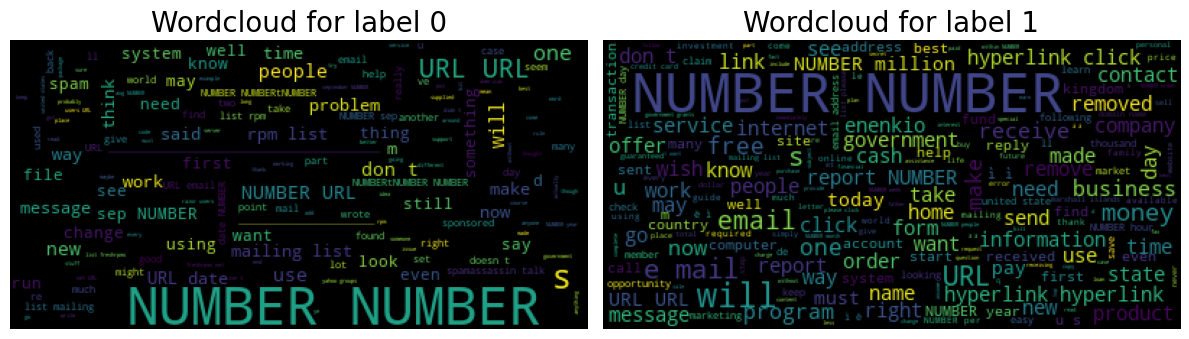

In [7]:
text_0 = ' '.join(df.loc[df.label == 0]['email'])
text_1 = ' '.join(df.loc[df.label == 1]['email'])

wordcloud_0 = WordCloud().generate(text_0)
wordcloud_1 = WordCloud().generate(text_1)

fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,6))

ax1.imshow(wordcloud_0)
ax1.axis("off")
ax1.set_title("Wordcloud for label 0",fontsize=20)

ax2.imshow(wordcloud_1)
ax2.axis("off")
ax2.set_title("Wordcloud for label 1",fontsize=20)

plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df['email'], df['label'], stratify=df['label'], 
                                                    test_size=TEST_SIZE, random_state=42)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [9]:
df_train.shape[0], df_test.shape[0]

(2099, 900)

In [10]:
def save_data(df, rootdir):
    with open(rootdir + '/features.txt', 'wt', errors='ignore') as feat_fh, \
        open(rootdir + '/labels.txt', 'wt', errors='ignore') as labl_fh:
        for idx, row in df.iterrows():
            lb = str(row['label']) + '\n'
            ft = row['email'].lower() + '\n'
            labl_fh.write(lb)
            feat_fh.write(ft)

In [11]:
save_data(df_train, TRAIN_DATA)
save_data(df_test, TEST_DATA)
df_test.to_csv(TEST_DATA + '/data_test.csv', index=False)

In [12]:
%%time
%runshell {MLTEXTCLASSIFIER} f 1 1 {path.join('model','model_CounterVectorizer_NaiveBayesClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,smoothing_param_m=1.0,smoothing_param_p=0.5

c:\users\rajas\appdata\local\programs\python\python39\lib\subprocess.py:937: RuntimeWarning: line buffering (buffering=1) isn't supported in binary mode, the default buffer size will be used
  self.stdout = io.open(c2pread, 'rb', bufsize)


Training
minfrequency = 2
smoothing_param_m = 1
smoothing_param_p = 0.5
No of Rare Words = 9939
Fitting CountVectorizer...
0 % done
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % do

In [13]:
%%time
%runshell {MLTEXTCLASSIFIER} f 2 1 {path.join('model','model_TfidfVectorizer_NaiveBayesClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,smoothing_param_m=1.0,smoothing_param_p=0.5

Training
minfrequency = 2
smoothing_param_m = 1
smoothing_param_p = 0.5
No of Rare Words = 9939
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % done
89 % d

In [14]:
%%time
%runshell {MLTEXTCLASSIFIER} f 1 2 {path.join('model','model_CounterVectorizer_LogisticRegressionClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 9939
Fitting CountVectorizer...
0 % done
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
8

In [15]:
%%time
%runshell {MLTEXTCLASSIFIER} f 2 2 {path.join('model','model_TfidfVectorizer_LogisticRegressionClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 9939
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done


In [16]:
%%time
%runshell {MLTEXTCLASSIFIER} f 1 3 {path.join('model','model_CounterVectorizer_SVCClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 9939
Fitting CountVectorizer...
0 % done
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
8

In [17]:
%%time
%runshell {MLTEXTCLASSIFIER} f 2 3 {path.join('model','model_TfidfVectorizer_SVCClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,bias=0.0,epochs=15,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
bias = 0
epochs = 15
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 9939
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done


In [18]:
%%time
%runshell {MLTEXTCLASSIFIER} f 1 5 {path.join('model','model_CounterVectorizer_RandomForestClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,num_trees=50,max_depth=5

Training
minfrequency = 2
num_trees = 50
max_depth = 5
No of Rare Words = 9939
Fitting CountVectorizer...
0 % done
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % done
89 % done
90 %

In [19]:
%%time
%runshell {MLTEXTCLASSIFIER} f 2 5 {path.join('model','model_TfidfVectorizer_RandomForestClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,num_trees=50,max_depth=5

Training
minfrequency = 2
num_trees = 50
max_depth = 5
No of Rare Words = 9939
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 % done
84 % done
85 % done
86 % done
87 % done
88 % done
89 % done
90 % done
91 

In [20]:
%%time
%runshell {MLTEXTCLASSIFIER} f 1 6 {path.join('model','model_CounterVectorizer_GradientBoostingClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,n_trees=50,max_depth=5,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
n_trees = 50
max_depth = 5
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 9939
Fitting CountVectorizer...
0 % done
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % 

In [21]:
%%time
%runshell {MLTEXTCLASSIFIER} f 2 6 {path.join('model','model_TfidfVectorizer_GradientBoostingClassifier.dat')} {path.join('data','train','features.txt')} {path.join('data','train','labels.txt')} 1.0 minfrequency=2,n_trees=50,max_depth=5,learning_rate=0.01,l1_regularization_param=0.001,l2_regularization_param=0.0

Training
minfrequency = 2
n_trees = 50
max_depth = 5
learning_rate = 0.01
l1_regularization_param = 0.001
l2_regularization_param = 0
No of Rare Words = 9939
fitting TfidfVectorizer...
1 % done
2 % done
3 % done
4 % done
5 % done
6 % done
7 % done
8 % done
9 % done
10 % done
11 % done
12 % done
13 % done
14 % done
15 % done
16 % done
17 % done
18 % done
19 % done
20 % done
21 % done
22 % done
23 % done
24 % done
25 % done
26 % done
27 % done
28 % done
29 % done
30 % done
31 % done
32 % done
33 % done
34 % done
35 % done
36 % done
37 % done
38 % done
39 % done
40 % done
41 % done
42 % done
43 % done
44 % done
45 % done
46 % done
47 % done
48 % done
49 % done
50 % done
51 % done
52 % done
53 % done
54 % done
55 % done
56 % done
57 % done
58 % done
59 % done
60 % done
61 % done
62 % done
63 % done
64 % done
65 % done
66 % done
67 % done
68 % done
69 % done
70 % done
71 % done
72 % done
73 % done
74 % done
75 % done
76 % done
77 % done
78 % done
79 % done
80 % done
81 % done
82 % done
83 %